In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [4]:
df = pd.read_csv('/content/car details v4.csv')
print(df.head())
print("\nShape :", df.shape)
print("\nColumns :")
print(df.columns)
print("\nData Types :")
print(df.dtypes)
print("\nDataset Information :")
df.info()

            Make                            Model    Price  Year  Kilometer  \
0          Honda              Amaze 1.2 VX i-VTEC   505000  2017      87150   
1  Maruti Suzuki                  Swift DZire VDI   450000  2014      75000   
2        Hyundai             i10 Magna 1.2 Kappa2   220000  2011      67000   
3         Toyota                         Glanza G   799000  2019      37500   
4         Toyota  Innova 2.4 VX 7 STR [2016-2020]  1950000  2018      69000   

  Fuel Type Transmission   Location   Color   Owner Seller Type   Engine  \
0    Petrol       Manual       Pune    Grey   First   Corporate  1198 cc   
1    Diesel       Manual   Ludhiana   White  Second  Individual  1248 cc   
2    Petrol       Manual    Lucknow  Maroon   First  Individual  1197 cc   
3    Petrol       Manual  Mangalore     Red   First  Individual  1197 cc   
4    Diesel       Manual     Mumbai    Grey   First  Individual  2393 cc   

            Max Power              Max Torque Drivetrain  Length   W

In [5]:
# Check missing values
missing_df = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum()/len(df))*100
})
missing_df = missing_df[missing_df["Missing Count"] > 0]
display(missing_df.sort_values("Missing %", ascending=False))
# Check duplicate rows
print("\nDuplicate Rows :", df.duplicated().sum())

,Missing Count,Missing %
Drivetrain,136,6.605148
Fuel Tank Capacity,113,5.488101
Engine,80,3.885381
Max Torque,80,3.885381
Max Power,80,3.885381
Length,64,3.108305
Width,64,3.108305
Height,64,3.108305
Seating Capacity,64,3.108305



Duplicate Rows : 0


In [6]:
# Fill missing values

# Numerical columns
numerical_cols = [
    "Length",
    "Width",
    "Height",
    "Seating Capacity",
    "Fuel Tank Capacity"
]
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())


# Categorical columns
categorical_cols = [
    "Engine",
    "Max Power",
    "Max Torque",
    "Drivetrain"
]
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verify missing values
df.isnull().sum()

,0
Make,0
Model,0
Price,0
Year,0
Kilometer,0
Fuel Type,0
Transmission,0
Location,0
Color,0
Owner,0


In [7]:
# Clean Engine column
df["Engine"] = df["Engine"].str.replace(" cc", "", regex=False)
df["Engine"] = df["Engine"].astype(float)
df["Engine"].head()

,Engine
0,1198.0
1,1248.0
2,1197.0
3,1197.0
4,2393.0


In [8]:
# Clean Max Power column
df["Max Power"] = df["Max Power"].str.extract(r'(\d+\.?\d*)')
df["Max Power"] = df["Max Power"].astype(float)
df["Max Power"].head()

,Max Power
0,87.0
1,74.0
2,79.0
3,82.0
4,148.0


In [9]:
# Clean Max Torque column
df["Max Torque"] = df["Max Torque"].str.extract(r'(\d+\.?\d*)')
df["Max Torque"] = df["Max Torque"].astype(float)
df["Max Torque"].head()

,Max Torque
0,109.0000
1,190.0000
2,112.7619
3,113.0000
4,343.0000


In [10]:
# Encode categorical columns
label_encoder = LabelEncoder()
categorical_columns = [
    "Make",
    "Model",
    "Fuel Type",
    "Transmission",
    "Location",
    "Color",
    "Owner",
    "Seller Type",
    "Drivetrain"
]
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])
df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,7,106,505000,2017,87150,6,1,56,7,1,1,1198.0,87.0,109.0000,1,3990.0,1680.0,1505.0,5.0,35.0
1,19,802,450000,2014,75000,2,1,40,15,3,2,1248.0,74.0,190.0000,1,3995.0,1695.0,1555.0,5.0,42.0
2,8,1030,220000,2011,67000,6,1,39,8,1,2,1197.0,79.0,112.7619,1,3585.0,1595.0,1550.0,5.0,35.0
3,30,492,799000,2019,37500,6,1,41,13,1,2,1197.0,82.0,113.0000,1,3995.0,1745.0,1510.0,5.0,37.0
4,30,548,1950000,2018,69000,2,1,45,7,1,2,2393.0,148.0,343.0000,2,4735.0,1830.0,1795.0,7.0,55.0


In [11]:
# Final dataset check
df.info()
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDataset Shape:")
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   int64  
 1   Model               2059 non-null   int64  
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   int64  
 6   Transmission        2059 non-null   int64  
 7   Location            2059 non-null   int64  
 8   Color               2059 non-null   int64  
 9   Owner               2059 non-null   int64  
 10  Seller Type         2059 non-null   int64  
 11  Engine              2059 non-null   float64
 12  Max Power           2059 non-null   float64
 13  Max Torque          2059 non-null   float64
 14  Drivetrain          2059 non-null   int64  
 15  Length              2059 non-null   float64
 16  Width 

In [12]:
# Separate features and target variable
X = df.drop("Price", axis=1)
y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [14]:
# Calculate the evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 301631.49
Mean Squared Error (MSE): 1269981654709.88
Root Mean Squared Error (RMSE): 1126934.63
R² Score: 0.8182


In [15]:
# Create a DataFrame of feature importances
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)
feature_importance

,Feature,Importance
11,Max Power,0.633162
2,Year,0.090540
18,Fuel Tank Capacity,0.080354
14,Length,0.046509
15,Width,0.040390
3,Kilometer,0.032711
12,Max Torque,0.015653
16,Height,0.012911
10,Engine,0.010558
1,Model,0.009341


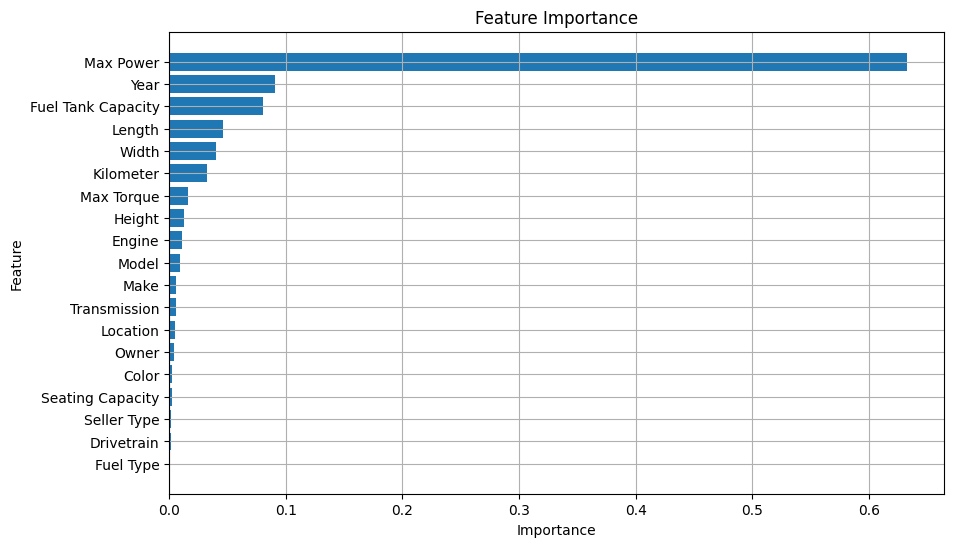

In [16]:
# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

In [17]:
# Compare actual and predicted prices
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})
comparison.head(10)

,Actual Price,Predicted Price
0,4800000,5021699.95
1,825000,789390.00
2,695000,568599.96
3,950000,967269.98
4,819999,776169.66
5,310000,375599.98
6,1000000,899990.00
7,1998999,2372429.94
8,850000,1795269.97
9,3950000,4720139.99


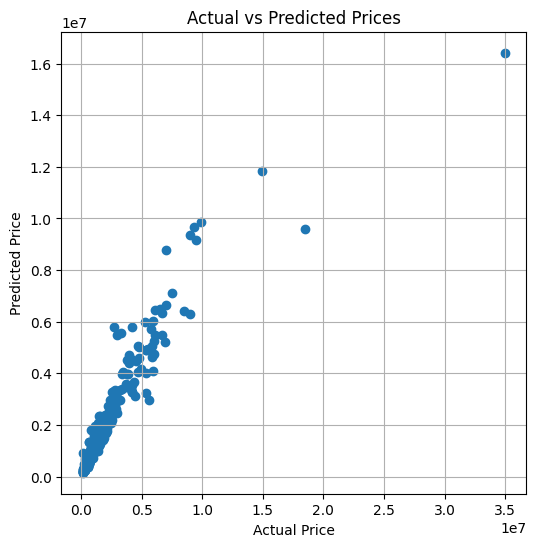

In [18]:
# Plot actual vs predicted prices
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.grid(True)
plt.show()

In [19]:
# Save the trained Random Forest model
import joblib
joblib.dump(model, "random_forest_model.pkl")

['random_forest_model.pkl']